In [300]:
from importlib import reload
import os
import sys
# Set up paths for utility imports
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')

os.chdir(current_dir)
# Ensure the utilities directory is in the import path
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
    
import plotting
import pinns
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from pinns import  MLP, init_weights 
import sympy as sp
torch.set_default_dtype(torch.float64)

In [301]:
def gradient_norm(loss, parameters):
    """
    Compute ||dL/dθ||_2 without modifying .grad.
    """

    grads = torch.autograd.grad(
        loss,
        parameters,
        retain_graph=True,
        allow_unused=True,
    )

    norm2 = 0.0

    for g in grads:
        if g is not None:
            norm2 += torch.sum(g**2)

    return torch.sqrt(norm2)

In [339]:
def coefficient_torch(X, epsilon=1.0):
    """
    Exact coefficient in PyTorch.

    Parameters
    ----------
    X : (N,2) tensor
        X[:,0] = x
        X[:,1] = y
    """

    y = X[:,1:2]

    return 1.0 + 2.0 / (1.0 + torch.exp(-y / epsilon))

In [349]:
def pde_loss(
    model_u,
    model_k,
    X,
    F,
    lambda_r=1e-3,
    use_regularizer=False,
):

    # --------------------------------------------------
    # Predictions
    # --------------------------------------------------

    u = model_u(X)
    k = model_k(X)
    #k = coefficient_torch(X)
    # --------------------------------------------------
    # grad(u)
    # --------------------------------------------------

    grad_u = torch.autograd.grad(
        u,
        X,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]

    ux = grad_u[:, 0:1]
    uy = grad_u[:, 1:2]

    # --------------------------------------------------
    # Fluxes
    # --------------------------------------------------

    qx = k * ux
    qy = k * uy

    grad_qx = torch.autograd.grad(
        qx,
        X,
        grad_outputs=torch.ones_like(qx),
        create_graph=True,
    )[0]

    grad_qy = torch.autograd.grad(
        qy,
        X,
        grad_outputs=torch.ones_like(qy),
        create_graph=True,
    )[0]

    div = (
        grad_qx[:, 0:1]
        + grad_qy[:, 1:2]
    )

    residual = -div - F

    # --------------------------------------------------
    # PDE loss
    # --------------------------------------------------

    loss_pde = torch.mean(residual**2)


    grad_k = torch.autograd.grad(
        k,
        X,
        grad_outputs=torch.ones_like(k),
        create_graph=True,
    )[0]

    dkdy = grad_k[:,1:2]
    lambda_s = 1e-3

    loss_smooth = lambda_s * torch.mean(dkdy**2)

    # --------------------------------------------------
    # No Double-PINN
    # --------------------------------------------------

    if not use_regularizer:

        total = loss_pde + loss_smooth

        return (
            total,
            loss_pde,
            torch.tensor(
                0.0,
                device=X.device,
                dtype=X.dtype,
            ),

        )

    # --------------------------------------------------
    # Double-PINN regularization
    # --------------------------------------------------

    grad_residual = torch.autograd.grad(
        residual,
        X,
        grad_outputs=torch.ones_like(residual),
        create_graph=True,
    )[0]

    reg_pde = (
        0.5
        * lambda_r
        * torch.mean(
            grad_residual.pow(2).sum(dim=1)
        )
    )



    total = (
        loss_pde
        + reg_pde
        
    )

    return (
        total,
        loss_pde,
        reg_pde
    )

In [350]:
def observation_loss_u(
    model_u,
    X,
    U_true,
    criterion,
    lambda_r=1e-3,
    use_regularizer=False,
):

    pred = model_u(X)

    mse = criterion(pred, U_true)

    if not use_regularizer:
        return mse, mse, torch.tensor(
            0.0,
            device=X.device,
            dtype=X.dtype,
        )

    X_reg = X.clone().detach().requires_grad_(True)

    pred = model_u(X_reg)

    error = pred - U_true

    grad = torch.autograd.grad(
        error,
        X_reg,
        grad_outputs=torch.ones_like(error),
        create_graph=True,
    )[0]

    reg = (
        0.5
        * lambda_r
        * torch.mean(
            grad.pow(2).sum(dim=1)
        )
    )

    return mse + reg, mse, reg

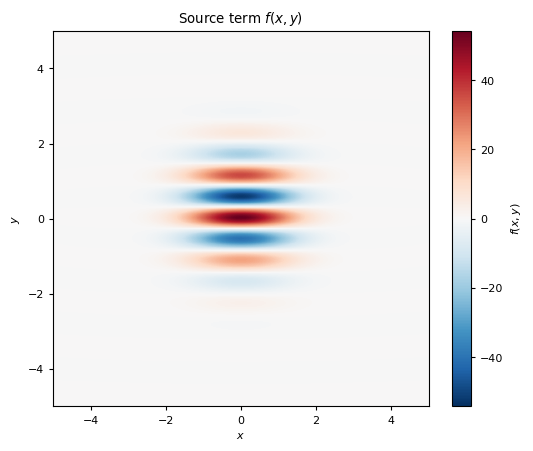

In [351]:
# --------------------------------------------------
# Dense grid
# --------------------------------------------------

x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)

F = source_term(X, Y)
# normalize the source term from -1 to 1
#F = F / np.max(np.abs(F))
# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(5.5, 4.5))

vmax = np.max(np.abs(F))

im = plt.imshow(
    F,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)

plt.colorbar(im, label=r"$f(x,y)$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Source term $f(x,y)$")
plt.gca().set_aspect("equal")

plt.tight_layout()
plt.show()

In [352]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------

alpha = 0.5
beta = 5
epsilon = 1.0


# Symbolic variables
xs, ys = sp.symbols("x y")
alpha_s, beta_s = sp.symbols("alpha beta", positive=True)
eps_s = sp.symbols("epsilon", positive=True)

# -------------------------
# Manufactured solution
# Infinite domain
# -------------------------
u = sp.exp(
    -alpha_s*(xs**2 + ys**2)
) * sp.cos(beta_s*ys)

k = 1 + 2/(1 + sp.exp(-ys/eps_s))

# -------------------------
# Poisson source term
# -------------------------
ux = sp.diff(u, xs)
uy = sp.diff(u, ys)

f = -(
    sp.diff(k*ux, xs)
    +
    sp.diff(k*uy, ys)
)

f = sp.simplify(f)


f_numpy = sp.lambdify(
    (xs, ys, alpha_s, beta_s, eps_s),
    f,
    "numpy",
)

def source_term(x, y):
    return f_numpy(x, y, 0.5, 5, 1.0)
# --------------------------------------------------
# Analytical solution
# --------------------------------------------------

def analytical_solution(x, y, alpha=alpha, beta=beta):
    """
    Analytical solution u(x,y).
    """
    return np.exp(-alpha * (x**2 + y**2)) * np.cos(beta * y)

In [353]:
class CoefficientNet(nn.Module):

    def __init__(
        self,
        hidden_layers=3,
        hidden_units=25,
        activation=nn.Tanh(),
    ):
        super().__init__()

        layers = []

        layers.append(nn.Linear(1, hidden_units))
        layers.append(activation)

        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_units, hidden_units))
            layers.append(activation)

        layers.append(nn.Linear(hidden_units, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, X):

        y = X[:,1:2]

        phi = self.net(y)

        return phi

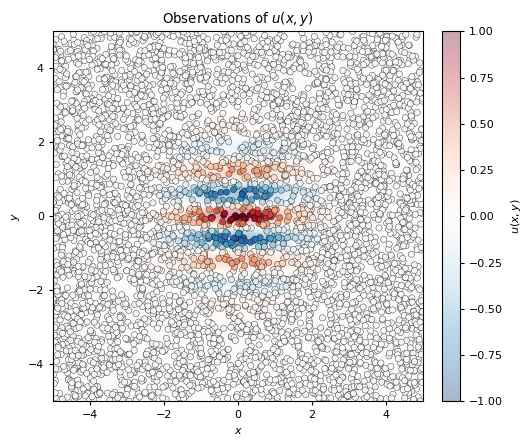


Training with Adam
Adam     0 | Total=8.193e-01 | ObsU=8.193e-01 | 
Adam   100 | Total=1.664e-02 | ObsU=1.664e-02 | 
Adam   200 | Total=1.651e-02 | ObsU=1.651e-02 | 
Adam   300 | Total=1.648e-02 | ObsU=1.648e-02 | 
Adam   400 | Total=1.646e-02 | ObsU=1.646e-02 | 
Adam   500 | Total=1.645e-02 | ObsU=1.645e-02 | 
Adam   600 | Total=1.643e-02 | ObsU=1.643e-02 | 
Adam   700 | Total=1.642e-02 | ObsU=1.642e-02 | 
Adam   800 | Total=1.641e-02 | ObsU=1.641e-02 | 
Adam   900 | Total=1.640e-02 | ObsU=1.640e-02 | 

Training with L-BFGS
L-BFGS   100 | Total=7.392e-03 | ObsU=7.392e-03 | 
L-BFGS   200 | Total=2.597e-03 | ObsU=2.597e-03 | 
L-BFGS   300 | Total=1.022e-03 | ObsU=1.022e-03 | 
L-BFGS   400 | Total=5.530e-04 | ObsU=5.530e-04 | 
L-BFGS   500 | Total=3.997e-04 | ObsU=3.997e-04 | 
L-BFGS   600 | Total=3.328e-04 | ObsU=3.328e-04 | 
L-BFGS   700 | Total=2.959e-04 | ObsU=2.959e-04 | 
L-BFGS   800 | Total=2.663e-04 | ObsU=2.663e-04 | 
L-BFGS   900 | Total=2.498e-04 | ObsU=2.498e-04 | 
L-BFGS  1

In [362]:

# --------------------------------------------------
# Parameters
# --------------------------------------------------

alpha = 0.5
beta = 5
epsilon = 1.0


# Symbolic variables
xs, ys = sp.symbols("x y")
alpha_s, beta_s = sp.symbols("alpha beta", positive=True)
eps_s = sp.symbols("epsilon", positive=True)

# -------------------------
# Manufactured solution
# Infinite domain
# -------------------------
u = sp.exp(
    -alpha_s*(xs**2 + ys**2)
) * sp.cos(beta_s*ys)

k = 1 + 2/(1 + sp.exp(-ys/eps_s))

# -------------------------
# Poisson source term
# -------------------------
ux = sp.diff(u, xs)
uy = sp.diff(u, ys)

f = -(
    sp.diff(k*ux, xs)
    +
    sp.diff(k*uy, ys)
)

f = sp.simplify(f)


f_numpy = sp.lambdify(
    (xs, ys, alpha_s, beta_s, eps_s),
    f,
    "numpy",
)

def source_term(x, y):
    return f_numpy(x, y, 0.5, 5, 1.0)
# --------------------------------------------------
# Analytical solution
# --------------------------------------------------

def analytical_solution(x, y, alpha=alpha, beta=beta):
    """
    Analytical solution u(x,y).
    """
    return np.exp(-alpha * (x**2 + y**2)) * np.cos(beta * y)


def coefficient(x, y, epsilon=epsilon):
    """
    Variable coefficient k(y).
    """
    return 1 + 2 / (1 + np.exp(-y / epsilon))

results = []
iter_train = 0

adam_lr        = 1e-3
hidden_layers_ = 3
hidden_units_  = 25
 
adam_iters     = 1_000
lbfgs_iters    = 1_000
activation_function_ = nn.Tanh()
use_regularizer = True      # or False
lambda_r = 1e-3

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model_u = MLP(
    input_size=2,
    output_size=1,
    hidden_layers=hidden_layers_,
    hidden_units=hidden_units_,
    activation_function=activation_function_,
).to(device).double()

model_u.apply(init_weights)

model_k = CoefficientNet(
    hidden_layers=3,
    hidden_units=25,
    activation=nn.Tanh(),
).to(device).double()

model_k.apply(init_weights)

np.random.seed(42)

N_obs = 5000

x_obs = np.random.uniform(-5, 5, N_obs)
y_obs = np.random.uniform(-5, 5, N_obs)

u_obs = analytical_solution(x_obs, y_obs)
#k_obs = coefficient(x_obs, y_obs)


# --------------------------------------------------
# PDE collocation points
# --------------------------------------------------

N_pde = 5000

x_pde = np.random.uniform(-5, 5, N_pde)
y_pde = np.random.uniform(-5, 5, N_pde)

f_pde = source_term(x_pde, y_pde)

# Dense field for visualization
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)
U = analytical_solution(X, Y)

 
# --------------------------------------------------
# Observation tensors
# --------------------------------------------------

X_obs = torch.tensor(
    np.column_stack((x_obs, y_obs)),
    dtype=torch.float64,
    device=device,
)

U_obs = torch.tensor(
    u_obs.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)

# K_obs = torch.tensor(
#     k_obs.reshape(-1,1),
#     dtype=torch.float64,
#     device=device,
# )

# --------------------------------------------------
# PDE tensors
# --------------------------------------------------

X_pde = torch.tensor(
    np.column_stack((x_pde, y_pde)),
    dtype=torch.float64,
    device=device,
    requires_grad=True,
)

F_pde = torch.tensor(
    f_pde.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)

# --------------------------------------------------
# u(x,y)
# --------------------------------------------------
plt.figure(figsize=(5.5, 4.5))

im = plt.imshow(
    U,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    alpha=0.35,
)

plt.scatter(
    x_obs,
    y_obs,
    c=u_obs,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    s=20,
    edgecolors="k",
    linewidths=0.25,
)

plt.title(r"Observations of $u(x,y)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.gca().set_aspect("equal")

cbar = plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(r"$u(x,y)$")

plt.tight_layout()
plt.show()

# ============================================================
# Training data
# ============================================================

X_train = torch.tensor(
    np.column_stack((x_obs, y_obs)),
    dtype=torch.float64,
    device=device,
)

U_train = torch.tensor(
    u_obs.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)

# ============================================================
# Training data
# ============================================================

X_train = torch.tensor(
    np.column_stack((x_obs, y_obs)),
    dtype=torch.float64,
    device=device,
)

U_train = torch.tensor(
    u_obs.reshape(-1,1),
    dtype=torch.float64,
    device=device,
)


# ------------------------------------------
# Boundary points for k(y)
# ------------------------------------------

X_k_bc = torch.tensor(
    [
        [0.0, -5.0],
        [0.0,  5.0],
    ],
    dtype=torch.float64,
    device=device,
)

K_bc = torch.tensor(
    coefficient(
        np.array([0.0, 0.0]),
        np.array([-5.0, 5.0]),
    ).reshape(-1,1),
    dtype=torch.float64,
    device=device,
)


def coefficient_boundary_loss(
    model_k,
    X_bc,
    K_bc,
    criterion,
):

    pred = model_k(X_bc)

    return criterion(pred, K_bc)

def train_dual_network(

    model_u,
    model_k,

    X_obs,
    U_obs,

    X_pde,
    F_pde,

    adam_lr=1e-3,
    adam_iters=1000,
    lbfgs_iters=2000,
    ):

    criterion = nn.MSELoss()

    # --------------------------------------------------------
    # Optimizers (parameters of both networks)
    # --------------------------------------------------------

    parameters = list(model_u.parameters()) + list(model_k.parameters())

    # Freeze k
    for p in model_k.parameters():
        p.requires_grad = False

    # Train u
    for p in model_u.parameters():
        p.requires_grad = True


    optimizer_adam = optim.Adam(
        model_u.parameters(),
        lr=adam_lr,
    )

    optimizer_lbfgs = optim.LBFGS(
        model_u.parameters(),
        lr=1.0,
        max_iter=lbfgs_iters,
        max_eval=lbfgs_iters,
        history_size=100,
        line_search_fn="strong_wolfe",
    )

    history = {
        "total": [],
        "u": [],
        "k": [],
        "pde": [],
        "grad_u": [],
        "grad_k": [],
        "grad_pde": [],
    }

    # ========================================================
    # Adam
    # ========================================================

    print("\n====================================")
    print("Training with Adam")
    print("====================================")

    model_u.train()
    model_k.train()

    for epoch in range(adam_iters):

        optimizer_adam.zero_grad()

        #pred_u = model_u(X_obs)
        #pred_k = model_k(X_obs)
        loss_u, mse_u, reg_u = observation_loss_u(
            model_u,
            X_obs,
            U_obs,
            criterion,
            lambda_r=lambda_r,
            use_regularizer=use_regularizer,
        )

        # loss_k, mse_k, reg_k = observation_loss_k(
        #     model_k,
        #     X_obs,
        #     K_obs,
        #     criterion,
        #     lambda_r=lambda_r,
        #     use_regularizer=use_regularizer,
        # )
    

        #parameters = list(model_u.parameters()) + list(model_k.parameters())

        # grad_u = gradient_norm(loss_u, parameters)
        # grad_k = gradient_norm(loss_k, parameters)
        # grad_pde = gradient_norm(loss_pde, parameters)

        loss = (
            loss_u
        )

        loss.backward()

        optimizer_adam.step()

        history["total"].append(loss.item())
        history["u"].append(loss_u.item())
        #history["k"].append(loss_k.item())
        #history["pde"].append(loss_pde.item())
        # history["grad_u"].append(grad_u.item())
        # history["grad_k"].append(grad_k.item())
        # history["grad_pde"].append(grad_pde.item())


        if epoch % 100 == 0:

            print(
                f"Adam {epoch:5d} | "
                f"Total={loss.item():.3e} | "
                f"ObsU={loss_u.item():.3e} | "
                # f"ObsK={loss_k.item():.3e} | "
                #f"PDE={loss_pde.item():.3e}\n"
                # f"             "
                # f"| ||∇U||={grad_u.item():.3e} "
                # f"| ||∇K||={grad_k.item():.3e} "
                # f"| ||∇PDE||={grad_pde.item():.3e}"
            )

    # ========================================================
    # L-BFGS
    # ========================================================

    print("\n====================================")
    print("Training with L-BFGS")
    print("====================================")

    state = {"iter": 0}

    def closure():

        optimizer_lbfgs.zero_grad()
 

        loss_u, mse_u, reg_u = observation_loss_u(
            model_u,
            X_obs,
            U_obs,
            criterion,
            lambda_r=lambda_r,
            use_regularizer=use_regularizer,
        )
 
 

        loss = (
                loss_u
            )

        loss.backward()

    

        history["total"].append(loss.item())
        history["u"].append(loss_u.item())
        # history["k"].append(loss_k.item())
        #history["pde"].append(loss_pde.item())
        # history["grad_u"].append(grad_u.item())
        # history["grad_k"].append(grad_k.item())
        # history["grad_pde"].append(grad_pde.item())

        state["iter"] += 1

        if state["iter"] % 100 == 0:

            print(
                f"L-BFGS {state['iter']:5d} | "
                f"Total={loss.item():.3e} | "
                f"ObsU={loss_u.item():.3e} | "
                # f"ObsK={loss_k.item():.3e} | "
                #f"PDE={loss_pde.item():.3e}\n"
                #f"             "
                #f"| ||∇U||={grad_u.item():.3e} "
                # f"| ||∇K||={grad_k.item():.3e} "
                #f"| ||∇PDE||={grad_pde.item():.3e}"
            )

    # for p in model_u.parameters():
    #     p.requires_grad = True

    # for p in model_k.parameters():
    #     p.requires_grad = True
    # # ========================================================
    # # Adam
    # # ========================================================

    # print("\n====================================")
    # print("Training with Adam")
    # print("====================================")

    # model_u.train()
    # model_k.train()

    # for epoch in range(adam_iters):

    #     optimizer_adam.zero_grad()

    #     #pred_u = model_u(X_obs)
    #     #pred_k = model_k(X_obs)
    #     loss_u, mse_u, reg_u = observation_loss_u(
    #         model_u,
    #         X_obs,
    #         U_obs,
    #         criterion,
    #         lambda_r=lambda_r,
    #         use_regularizer=use_regularizer,
    #     )

    #     # loss_k, mse_k, reg_k = observation_loss_k(
    #     #     model_k,
    #     #     X_obs,
    #     #     K_obs,
    #     #     criterion,
    #     #     lambda_r=lambda_r,
    #     #     use_regularizer=use_regularizer,
    #     # )

    #     loss_pde, mse_pde, reg_pde = pde_loss(
    #         model_u,
    #         model_k,
    #         X_pde,
    #         F_pde,
    #         lambda_r=lambda_r,
    #         use_regularizer=use_regularizer,
    #     )

    #     loss_k_bc = coefficient_boundary_loss(
    #     model_k,
    #     X_k_bc,
    #     K_bc,
    #     criterion,
    #     )    

    #     #parameters = list(model_u.parameters()) + list(model_k.parameters())

    #     # grad_u = gradient_norm(loss_u, parameters)
    #     # grad_k = gradient_norm(loss_k, parameters)
    #     # grad_pde = gradient_norm(loss_pde, parameters)

    #     loss = (
    #         loss_u
    #         #+ loss_k
    #         + loss_pde
    #         + loss_k_bc
    #     )

    #     loss.backward()

    #     optimizer_adam.step()

    #     history["total"].append(loss.item())
    #     history["u"].append(loss_u.item())
    #     #history["k"].append(loss_k.item())
    #     #history["pde"].append(loss_pde.item())
    #     # history["grad_u"].append(grad_u.item())
    #     # history["grad_k"].append(grad_k.item())
    #     # history["grad_pde"].append(grad_pde.item())


    #     if epoch % 100 == 0:

    #         print(
    #             f"Adam {epoch:5d} | "
    #             f"Total={loss.item():.3e} | "
    #             f"ObsU={loss_u.item():.3e} | "
    #             # f"ObsK={loss_k.item():.3e} | "
    #             #f"PDE={loss_pde.item():.3e}\n"
    #             # f"             "
    #             # f"| ||∇U||={grad_u.item():.3e} "
    #             # f"| ||∇K||={grad_k.item():.3e} "
    #             # f"| ||∇PDE||={grad_pde.item():.3e}"
    #         )

    # # ========================================================
    # # L-BFGS
    # # ========================================================

    # print("\n====================================")
    # print("Training with L-BFGS")
    # print("====================================")

    # state = {"iter": 0}

    # def closure():

    #     optimizer_lbfgs.zero_grad()
 

    #     loss_u, mse_u, reg_u = observation_loss_u(
    #         model_u,
    #         X_obs,
    #         U_obs,
    #         criterion,
    #         lambda_r=lambda_r,
    #         use_regularizer=use_regularizer,
    #     )

    #     # loss_k, mse_k, reg_k = observation_loss_k(
    #     #     model_k,
    #     #     X_obs,
    #     #     K_obs,
    #     #     criterion,
    #     #     lambda_r=lambda_r,
    #     #     use_regularizer=use_regularizer,
    #     # )

    #     loss_pde, mse_pde, reg_pde = pde_loss(
    #         model_u,
    #         model_k,
    #         X_pde,
    #         F_pde,
    #         lambda_r=lambda_r,
    #         use_regularizer=use_regularizer,
    #     )

    #     loss_k_bc = coefficient_boundary_loss(
    #     model_k,
    #     X_k_bc,
    #     K_bc,
    #     criterion,
    #     ) 
    #     # parameters = list(model_u.parameters()) + list(model_k.parameters())

    #     # grad_u = gradient_norm(loss_u, parameters)
    #     # grad_k = gradient_norm(loss_k, parameters)
    #     # grad_pde = gradient_norm(loss_pde, parameters)

    #     loss = (
    #             loss_u
    #             #+ loss_k
    #             + loss_pde
    #             + loss_k_bc
    #         )

    #     loss.backward()

    

    #     history["total"].append(loss.item())
    #     history["u"].append(loss_u.item())
    #     # history["k"].append(loss_k.item())
    #     #history["pde"].append(loss_pde.item())
    #     # history["grad_u"].append(grad_u.item())
    #     # history["grad_k"].append(grad_k.item())
    #     # history["grad_pde"].append(grad_pde.item())

    #     state["iter"] += 1

    #     if state["iter"] % 100 == 0:

    #         print(
    #             f"L-BFGS {state['iter']:5d} | "
    #             f"Total={loss.item():.3e} | "
    #             f"ObsU={loss_u.item():.3e} | "
    #             # f"ObsK={loss_k.item():.3e} | "
    #             #f"PDE={loss_pde.item():.3e}\n"
    #             #f"             "
    #             #f"| ||∇U||={grad_u.item():.3e} "
    #             # f"| ||∇K||={grad_k.item():.3e} "
    #             #f"| ||∇PDE||={grad_pde.item():.3e}"
    #         )

        return loss

    optimizer_lbfgs.step(closure)

    return history

history = train_dual_network(

    model_u=model_u,
    model_k=model_k,

    X_obs=X_obs,
    U_obs=U_obs,

    X_pde=X_pde,
    F_pde=F_pde,

    adam_lr=adam_lr,
    adam_iters=adam_iters,
    lbfgs_iters=lbfgs_iters,
)

Relative L2 error (u): 4.795e-02
Relative L2 error (k): 1.027e+00


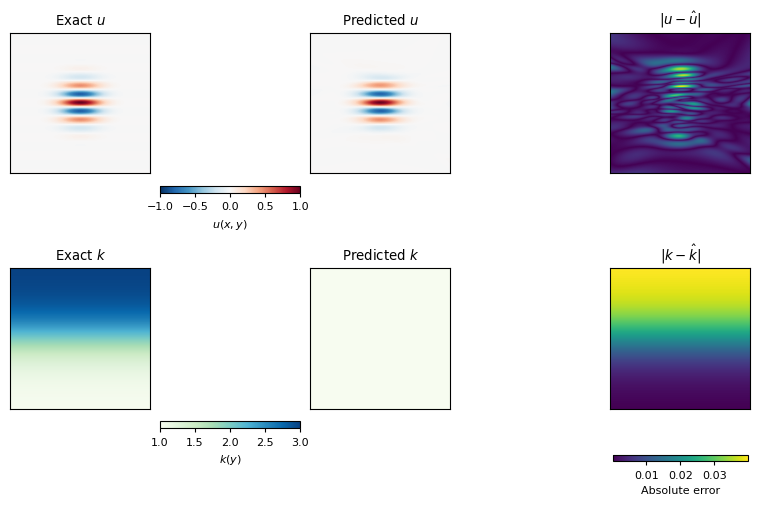

In [363]:
X_test = torch.tensor(
    np.column_stack((X.ravel(), Y.ravel())),
    dtype=torch.float64,
    device=device,
)

model_u.eval()
model_k.eval()

with torch.no_grad():

    U_pred = model_u(X_test)
    K_pred = model_k(X_test)

U_pred = U_pred.cpu().numpy().reshape(U.shape)
K_pred = K_pred.cpu().numpy().reshape(U.shape)

K_exact = coefficient(X, Y)

# ============================================================
# Relative errors
# ============================================================

err_u = np.linalg.norm(U_pred - U) / np.linalg.norm(U)
err_k = np.linalg.norm(K_pred - K_exact) / np.linalg.norm(K_exact)

print(f"Relative L2 error (u): {err_u:.3e}")
print(f"Relative L2 error (k): {err_k:.3e}")

# ============================================================
# Absolute errors
# ============================================================

error_u = np.abs(U_pred - U)
error_k = np.abs(K_pred - K_exact)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    2,
    3,
    figsize=(9, 5),
    constrained_layout=True,
)

# ------------------------------------------------------------
# u(x,y)
# ------------------------------------------------------------

im = ax[0,0].imshow(
    U,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

ax[0,0].set_title("Exact $u$")
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])

im = ax[0,1].imshow(
    U_pred,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

ax[0,1].set_title("Predicted $u$")
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])

im = ax[0,2].imshow(
    error_u,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="viridis",
)

ax[0,2].set_title(r"$|u-\hat u|$")
ax[0,2].set_xticks([])
ax[0,2].set_yticks([])

# ------------------------------------------------------------
# k(x,y)
# ------------------------------------------------------------

im = ax[1,0].imshow(
    K_exact,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
)

ax[1,0].set_title("Exact $k$")
ax[1,0].set_xticks([])
ax[1,0].set_yticks([])

im = ax[1,1].imshow(
    K_pred,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
)

ax[1,1].set_title("Predicted $k$")
ax[1,1].set_xticks([])
ax[1,1].set_yticks([])

im = ax[1,2].imshow(
    error_k,
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="viridis",
)

ax[1,2].set_title(r"$|k-\hat k|$")
ax[1,2].set_xticks([])
ax[1,2].set_yticks([])

# ------------------------------------------------------------
# Colorbars
# ------------------------------------------------------------

cbar1 = fig.colorbar(
    ax[0,1].images[0],
    ax=ax[0,:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
)

cbar1.set_label(r"$u(x,y)$")

cbar2 = fig.colorbar(
    ax[1,1].images[0],
    ax=ax[1,:2],
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
)

cbar2.set_label(r"$k(y)$")

cbar3 = fig.colorbar(
    ax[0,2].images[0],
    ax=ax[:,2],
    orientation="horizontal",
    fraction=0.018,
    pad=0.12,
)

cbar3.set_label("Absolute error")

plt.show()

In [332]:
# ============================================================
# PDE residual of the trained networks
# ============================================================

X_test = X_test.clone().detach().requires_grad_(True)

# u = model_u(X_test)
# k = model_k(X_test)


x = X_test[:,0:1]
y = X_test[:,1:2]

# --------------------------------------------------
# Exact solution
# --------------------------------------------------

u = torch.exp(
    -alpha*(x**2 + y**2)
) * torch.cos(beta*y)

k = 1 + 2/(1 + torch.exp(-y/epsilon))

# ------------------------------------------
# grad(u)
# ------------------------------------------

grad_u = torch.autograd.grad(
    u,
    X_test,
    grad_outputs=torch.ones_like(u),
    create_graph=True,
)[0]

ux = grad_u[:, 0:1]
uy = grad_u[:, 1:2]

# ------------------------------------------
# flux = k grad(u)
# ------------------------------------------

qx = k * ux
qy = k * uy

grad_qx = torch.autograd.grad(
    qx,
    X_test,
    grad_outputs=torch.ones_like(qx),
    create_graph=True,
)[0]

grad_qy = torch.autograd.grad(
    qy,
    X_test,
    grad_outputs=torch.ones_like(qy),
    create_graph=True,
)[0]

div = (
    grad_qx[:, 0:1]
    +
    grad_qy[:, 1:2]
)

# ------------------------------------------
# exact source term
# ------------------------------------------

F_test = torch.tensor(
    source_term(
        X.ravel(),
        Y.ravel(),
    ).reshape(-1,1),
    dtype=torch.float64,
    device=device,
)

residual = -div - F_test

print(f"PDE MSE       : {torch.mean(residual**2).item():.3e}")
print(f"Mean residual : {torch.mean(torch.abs(residual)).item():.3e}")
print(f"Max residual  : {torch.max(torch.abs(residual)).item():.3e}")

Residual = (
    residual
    .detach()
    .cpu()
    .numpy()
    .reshape(U.shape)
)

PDE MSE       : 2.713e-30
Mean residual : 4.226e-16
Max residual  : 2.842e-14


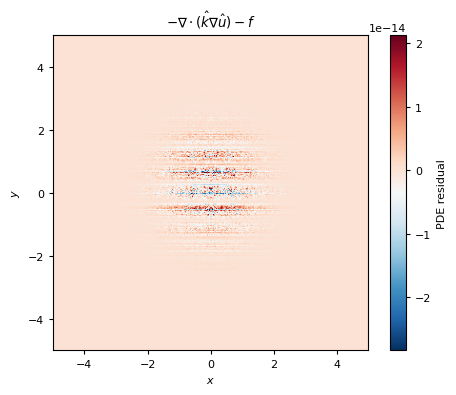

In [322]:
plt.figure(figsize=(5,4))

im = plt.imshow(
    residual.detach().cpu().numpy().reshape(U.shape),
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="RdBu_r",
)

plt.colorbar(im, label="PDE residual")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"$-\nabla\cdot(\hat{k}\nabla\hat{u})-f$")

plt.tight_layout()
plt.show()

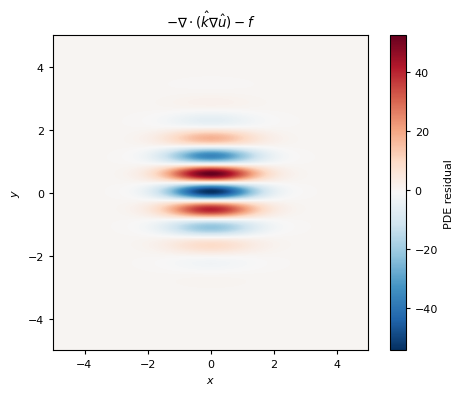

In [ ]:
plt.figure(figsize=(5,4))

im = plt.imshow(
    div.detach().cpu().numpy().reshape(U.shape),
    extent=[-5,5,-5,5],
    origin="lower",
    cmap="RdBu_r",
)

plt.colorbar(im, label="PDE residual")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"$-\nabla\cdot(\hat{k}\nabla\hat{u})-f$")

plt.tight_layout()
plt.show()

In [ ]:
print(next(model_u.parameters()).dtype)
print(X_obs.dtype)
print(div.dtype)

torch.float64
torch.float64
torch.float64
